In [4]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)

import seaborn as sns


In [5]:

import os

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root,file))


/kaggle/input/datasets/upalbackup30/bankdata/bank-data/bank-full.csv


In [6]:

data_path = "/kaggle/input/datasets/upalbackup30/bankdata/bank-data/bank-full.csv"

df = pd.read_csv(
    data_path,
    sep=";"
)

df.head()


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [7]:

print("Dataset Shape:", df.shape)

df.info()

df.isnull().sum()


Dataset Shape: (45211, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [8]:

df["y"].value_counts()


y
no     39922
yes     5289
Name: count, dtype: int64

In [9]:

X = df.drop("y", axis=1)
y = df["y"].map({
    "yes":1,
    "no":0
})

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)


(36168, 16)
(9043, 16)


In [10]:

categorical_features = X.select_dtypes(
    include="object"
).columns

numerical_features = X.select_dtypes(
    exclude="object"
).columns

print("Categorical:", list(categorical_features))
print("Numerical:", list(numerical_features))


Categorical: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
Numerical: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


In [12]:

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_features
        )
    ]
)


model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced"
            )
        )
    ]
)


In [20]:
# Apply preprocessing

X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)


print("Training shape:", X_train_processed.shape)
print("Testing shape:", X_test_processed.shape)

Training shape: (36168, 51)
Testing shape: (9043, 51)


In [13]:

model.fit(
    X_train,
    y_train
)

print("Training completed")


Training completed


In [14]:

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

accuracy = accuracy_score(
    y_test,
    y_pred
)

auc = roc_auc_score(
    y_test,
    y_prob
)

print("Accuracy:", accuracy)
print("ROC-AUC:", auc)

print(
    classification_report(
        y_test,
        y_pred
    )
)


Accuracy: 0.8457370341700763
ROC-AUC: 0.9079218714674134
              precision    recall  f1-score   support

           0       0.97      0.85      0.91      7985
           1       0.42      0.81      0.55      1058

    accuracy                           0.85      9043
   macro avg       0.70      0.83      0.73      9043
weighted avg       0.91      0.85      0.87      9043



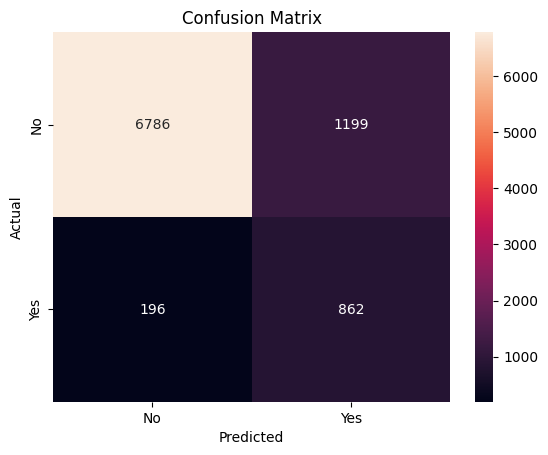

In [15]:

cm = confusion_matrix(
    y_test,
    y_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["No","Yes"],
    yticklabels=["No","Yes"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


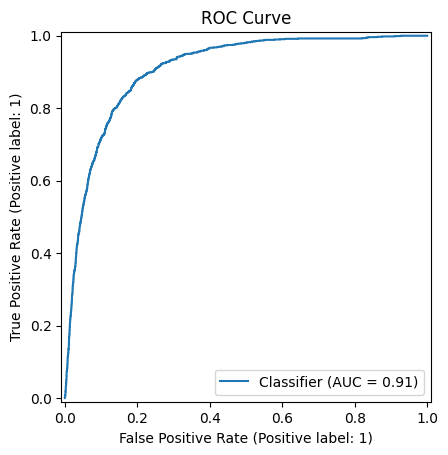

In [16]:

RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("ROC Curve")
plt.show()


In [21]:
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score


# Apply SMOTE
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)


print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())


# XGBoost model
xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)


# Train
xgb_model.fit(
    X_train_smote,
    y_train_smote
)


# Prediction
xgb_pred = xgb_model.predict(X_test_processed)

xgb_prob = xgb_model.predict_proba(
    X_test_processed
)[:,1]


print("Accuracy:",
      accuracy_score(y_test,xgb_pred))


print("ROC-AUC:",
      roc_auc_score(y_test,xgb_prob))


print(
classification_report(
    y_test,
    xgb_pred
)
)

Before SMOTE:
y
0    31937
1     4231
Name: count, dtype: int64

After SMOTE:
y
0    31937
1    31937
Name: count, dtype: int64
Accuracy: 0.9063363927900033
ROC-AUC: 0.9301885742762007
              precision    recall  f1-score   support

           0       0.95      0.94      0.95      7985
           1       0.59      0.64      0.61      1058

    accuracy                           0.91      9043
   macro avg       0.77      0.79      0.78      9043
weighted avg       0.91      0.91      0.91      9043



In [22]:
from sklearn.metrics import classification_report, accuracy_score


# Try different threshold

for threshold in [0.3,0.35,0.4,0.45,0.5]:

    pred = (xgb_prob >= threshold).astype(int)

    print("\nThreshold:", threshold)

    print(
        classification_report(
            y_test,
            pred
        )
    )


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.97      0.89      0.93      7985
           1       0.48      0.80      0.60      1058

    accuracy                           0.88      9043
   macro avg       0.73      0.84      0.77      9043
weighted avg       0.91      0.88      0.89      9043


Threshold: 0.35
              precision    recall  f1-score   support

           0       0.97      0.90      0.93      7985
           1       0.51      0.78      0.62      1058

    accuracy                           0.89      9043
   macro avg       0.74      0.84      0.78      9043
weighted avg       0.91      0.89      0.90      9043


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.96      0.92      0.94      7985
           1       0.54      0.74      0.62      1058

    accuracy                           0.89      9043
   macro avg       0.75      0.83      0.78      9043
weighted avg       0.91  

In [23]:
final_threshold = 0.35

final_pred = (xgb_prob >= final_threshold).astype(int)

print("Final Accuracy:")
print(accuracy_score(y_test, final_pred))

print("\nFinal Classification Report:")
print(classification_report(y_test, final_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, final_pred))

Final Accuracy:
0.8872055733716687

Final Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.90      0.93      7985
           1       0.51      0.78      0.62      1058

    accuracy                           0.89      9043
   macro avg       0.74      0.84      0.78      9043
weighted avg       0.91      0.89      0.90      9043


Confusion Matrix:
[[7201  784]
 [ 236  822]]


In [25]:

import joblib

joblib.dump(
    model,
    "bank_term_deposit_logistic_model.pkl"
)

print("Model saved successfully")


Model saved successfully
